# Exploratory Data Analysis (EDA)

This notebook documents the initial data understanding phase for the KKBox churn project. The goal is to build a clear view of the raw and aggregated tables before feature engineering and modeling.

What this notebook covers:

1. Understand the structure and quality of each input table.
2. Check missing values, duplicates, and data type consistency.
3. Explore distributions, category balance, and target leakage risks.
4. Identify likely transformations, feature ideas, and modeling constraints.
5. Produce a concise summary of the most important findings and follow-up actions.

The analysis is intentionally practical: every section should help inform downstream feature engineering, model selection, and validation design.

In [15]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sys.path.append(str(Path.cwd().parent))
warnings.filterwarnings('ignore')

from src.data.loader import load_all_tables
from src.data.merger import build_modeling_frame
from src.utils.config import get_path, load_config
from src.utils.logger import setup_logger

# Find the project root so the notebook works from either the repo root or notebooks/.
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / 'config' / 'config.yaml').exists():
    project_root = project_root.parent

config_path = project_root / 'config' / 'config.yaml'
config = load_config(config_path)
logger = setup_logger('eda', level='INFO')

raw_dir = get_path(config, 'raw_dir')
interim_dir = get_path(config, 'interim_dir')
processed_dir = get_path(config, 'processed_dir')
figures_dir = get_path(config, 'figures_dir')

if not raw_dir.is_absolute():
    raw_dir = project_root / raw_dir
if not interim_dir.is_absolute():
    interim_dir = project_root / interim_dir
if not processed_dir.is_absolute():
    processed_dir = project_root / processed_dir
if not figures_dir.is_absolute():
    figures_dir = project_root / figures_dir

figures_dir.mkdir(parents=True, exist_ok=True)

# A single consistent style makes the EDA output easier to scan and compare.
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print(f'Project root : {project_root}')
print(f'Config file  : {config_path}')
print(f'Raw dir      : {raw_dir}')
print(f'Figures dir  : {figures_dir}')

Project root : c:\Users\ADMIN\Documents\project_churn_prediction
Config file  : c:\Users\ADMIN\Documents\project_churn_prediction\config\config.yaml
Raw dir      : c:\Users\ADMIN\Documents\project_churn_prediction\data\raw
Figures dir  : c:\Users\ADMIN\Documents\project_churn_prediction\reports\figures


## 1 — Setup and imports

Prepare the notebook environment by importing analysis libraries, loading the shared project configuration, and setting display options for pandas and plotting.

Checklist:
- Load the project root and configuration file.
- Import reusable helpers for logging, paths, and data loading.
- Configure notebook display settings so tables and charts are easy to read.
- Keep the setup lightweight so the remaining sections can focus on analysis rather than boilerplate.

In [16]:
required_outputs = {
    'train': interim_dir / 'train.parquet',
    'members': interim_dir / 'members.parquet',
    'transactions': interim_dir / 'transactions_summary.parquet',
    'user_logs': interim_dir / 'user_logs_summary.parquet',
    'modeling_frame': interim_dir / 'modeling_frame.parquet',
}

missing_outputs = [name for name, path in required_outputs.items() if not path.exists()]
if missing_outputs:
    raise FileNotFoundError(
        'Missing ingested files in data/interim: '
        + ', '.join(missing_outputs)
        + '. Run src/data/run_ingestion.py first.'
    )

train = pd.read_parquet(required_outputs['train'])
members = pd.read_parquet(required_outputs['members'])
transactions = pd.read_parquet(required_outputs['transactions'])
user_logs = pd.read_parquet(required_outputs['user_logs'])
modeling_frame = pd.read_parquet(required_outputs['modeling_frame'])

tables = {
    'train': train,
    'members': members,
    'transactions': transactions,
    'user_logs': user_logs,
}

print('Loaded ingested tables:')
for name, frame in tables.items():
    print(f'- {name:18s}: {frame.shape[0]:,} rows x {frame.shape[1]} columns')

print(f"\nModeling frame: {modeling_frame.shape[0]:,} rows x {modeling_frame.shape[1]} columns")
print('\nTarget balance in train:')
print(train['is_churn'].value_counts(dropna=False).to_string())
print(f"Churn rate: {train['is_churn'].mean() * 100:.2f}%")

Loaded ingested tables:
- train             : 992,931 rows x 2 columns
- members           : 6,769,473 rows x 6 columns
- transactions      : 2,363,626 rows x 14 columns
- user_logs         : 5,234,111 rows x 15 columns

Modeling frame: 992,931 rows x 34 columns

Target balance in train:
is_churn
0    929460
1     63471
Churn rate: 6.39%


## 2 — Load ingested data

Load the compact Parquet outputs from `data/interim/` instead of the raw CSV files. This keeps the notebook fast, reproducible, and safe to run on a standard laptop.

Expected inputs:
- `train.parquet` for the target label and base identifier table.
- `members.parquet` for user profile attributes.
- `transactions_summary.parquet` for aggregated payment behavior.
- `user_logs_summary.parquet` for aggregated usage behavior.
- `modeling_frame.parquet` for the final merged analysis frame.

At this stage, verify that each table loads successfully and that the row counts and key columns look consistent before starting deeper analysis.

In [17]:
def audit_frame(frame: pd.DataFrame, name: str) -> None:
    """Print a compact audit summary for one dataframe."""
    print(f'\n=== {name.upper()} ===')
    print(f'Shape: {frame.shape[0]:,} rows x {frame.shape[1]} columns')
    print('\nHead:')
    display(frame.head())
    print('\nDtypes:')
    display(frame.dtypes.astype(str).to_frame('dtype'))
    null_summary = (
        frame.isna()
        .sum()
        .rename('null_count')
        .to_frame()
        .assign(null_pct=lambda x: x['null_count'] / len(frame) * 100)
        .query('null_count > 0')
        .sort_values('null_pct', ascending=False)
    )
    print('\nMissing values:')
    if null_summary.empty:
        print('No missing values detected.')
    else:
        display(null_summary)

for table_name in ['train', 'members', 'transactions', 'user_logs']:
    audit_frame(tables[table_name], table_name)


=== TRAIN ===
Shape: 992,931 rows x 2 columns

Head:


,msno,is_churn
0,waLDQMmcOu2jLDaV1ddDkgCrB/jl6sD66Xzs0Vqax1Y=,1
1,QA7uiXy8vIbUSPOkCf9RwQ3FsT8jVq2OxDr8zqa7bRQ=,1
2,fGwBva6hikQmTJzrbz/2Ezjm5Cth5jZUNvXigKK2AFA=,1
3,mT5V8rEpa+8wuqi6x0DoVd3H5icMKkE9Prt49UlmK+4=,1
4,XaPhtGLk/5UvvOYHcONTwsnH97P4eGECeq+BARGItRw=,1



Dtypes:


,dtype
msno,string
is_churn,Int64



Missing values:
No missing values detected.

=== MEMBERS ===
Shape: 6,769,473 rows x 6 columns

Head:


...


Missing values:
No missing values detected.

=== USER_LOGS ===
Shape: 5,234,111 rows x 15 columns

Head:


,msno,active_days,total_secs,mean_secs,total_25,total_50,total_75,total_985,total_100,total_unq,mean_unq,completion_rate,mean_completion_rate,last_log_date,days_since_last_log
0,+++4vcS9aMH7KWdfh5git6nA5fC5jjisd5H/NcM++WM=,1,9.741100e+01,97.411000,1.0,1.0,0.0,0.0,0.0,2.0,2.000000,0.000000,0.000000,2015-04-27,673
1,+++EI4HgyhgcJHIPXk/VRP7bt17+2joG39T6oEfJ+tc=,1,5.686800e+01,56.868000,2.0,0.0,0.0,0.0,0.0,1.0,1.000000,0.000000,0.000000,2016-04-20,314
2,+++FOrTS7ab3tIgIh8eWwX4FqRv8w/FoiOuyXsFvphY=,7,4.999677e+04,7142.395857,60.0,12.0,14.0,7.0,171.0,179.0,25.571429,0.647727,0.732361,2016-09-15,166
3,+++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=,622,1.466484e+07,23576.915444,817.0,249.0,227.0,195.0,59354.0,53604.0,86.180064,0.975543,0.925875,2017-02-27,1
4,+++TipL0Kt3JvgNE9ahuJ8o+drJAnQINtxD4c5GePXI=,1,3.661527e+03,3661.527000,3.0,3.0,2.0,1.0,14.0,22.0,22.000000,0.608696,0.608696,2015-12-30,426



Dtypes:


,dtype
msno,string
active_days,int64
total_secs,float64
mean_secs,float64
total_25,float64
total_50,float64
total_75,float64
total_985,float64
total_100,float64
total_unq,float64



Missing values:
No missing values detected.


## 3 — Data audit

Perform a structured audit of every table before any transformation. The objective is to understand the schema, the granularity of each dataset, and any obvious data quality issues.

Audit checks:
- Confirm row counts and column names.
- Inspect data types and parse dates where needed.
- Identify identifier columns and table grain.
- Flag unexpected null patterns, type mismatches, or suspicious value ranges.

A good audit should answer one simple question: can this table be trusted as-is, or does it need additional cleaning before analysis and modeling?

In [18]:
def normalize_columns(frame: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with normalized column names and basic date parsing."""
    normalized = frame.copy()
    normalized.columns = (
        normalized.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(' ', '_', regex=False)
    )
    for column in normalized.columns:
        if 'date' in column and not pd.api.types.is_datetime64_any_dtype(normalized[column]):
            parsed = pd.to_datetime(normalized[column], errors='ignore')
            if pd.api.types.is_datetime64_any_dtype(parsed):
                normalized[column] = parsed
    return normalized

analysis_tables = {name: normalize_columns(frame) for name, frame in tables.items()}
for name, frame in analysis_tables.items():
    print(f'{name:18s}: {list(frame.columns[:8])}')

train             : ['msno', 'is_churn']
members           : ['msno', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time']
transactions      : ['msno', 'trans_count', 'total_spend', 'mean_spend', 'max_spend', 'cancel_count', 'cancel_rate', 'auto_renew_rate']
user_logs         : ['msno', 'active_days', 'total_secs', 'mean_secs', 'total_25', 'total_50', 'total_75', 'total_985']


## 4 — Cleaning and normalization

Standardize the data so the EDA is performed on a consistent working copy rather than on the raw inputs. This section should make later summaries easier to interpret and less error-prone.

Typical normalization steps:
- Harmonize column names and feature naming conventions.
- Convert date and timestamp columns into proper datetime types.
- Enforce numeric, categorical, and boolean dtypes where appropriate.
- Create any analysis-ready helper columns needed for plotting or grouping.

The goal is not to perform heavy feature engineering here, but to make the tables stable enough for reliable descriptive analysis.

In [19]:
def missing_summary(frame: pd.DataFrame) -> pd.DataFrame:
    """Build a missing-value summary sorted by percentage."""
    summary = (
        frame.isna()
        .sum()
        .rename('null_count')
        .to_frame()
        .assign(null_pct=lambda x: x['null_count'] / len(frame) * 100)
        .query('null_count > 0')
        .sort_values('null_pct', ascending=False)
    )
    return summary

for table_name, frame in analysis_tables.items():
    summary = missing_summary(frame)
    print(f'\n{table_name.upper()} missing values:')
    if summary.empty:
        print('No missing values detected.')
        continue
    display(summary.style.background_gradient(cmap='Oranges'))

train_missing = missing_summary(analysis_tables['train'])
if not train_missing.empty:
    fig, ax = plt.subplots(figsize=(12, max(4, 0.35 * len(train_missing))))
    ax.barh(train_missing.index.astype(str), train_missing['null_pct'], color='#E8694C')
    ax.set_title('Train missing value percentage by column')
    ax.set_xlabel('Missing percentage')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(figures_dir / '01_missing_values_train.png', bbox_inches='tight')
    plt.show()


TRAIN missing values:
No missing values detected.

MEMBERS missing values:


,null_count,null_pct
gender,4429505,65.433528



TRANSACTIONS missing values:
No missing values detected.

USER_LOGS missing values:
No missing values detected.


## 5 — Missing values

Measure missingness both at the column level and at the row level. Missing values are often one of the strongest signals about data collection gaps, optional fields, or records that require special handling.

What to examine:
- Missing rate per column and per table.
- Whether missingness is concentrated in specific subsets of users or events.
- Whether missingness appears random or systematic.
- Practical imputation or exclusion strategies for downstream modeling.

This section should end with a clear view of which variables are safe to keep, which need imputation, and which may be better excluded from modeling.

In [20]:
duplicate_checks = []
for table_name, frame in analysis_tables.items():
    dup_all = int(frame.duplicated().sum())
    dup_msno = int(frame.duplicated(subset=['msno']).sum()) if 'msno' in frame.columns else np.nan
    duplicate_checks.append({'table': table_name, 'duplicate_rows': dup_all, 'duplicate_msno_rows': dup_msno})

duplicate_df = pd.DataFrame(duplicate_checks)
display(duplicate_df)

train_dupes = analysis_tables['train'].duplicated().sum()
print(f'Train exact duplicates: {train_dupes:,}')

if 'msno' in analysis_tables['train'].columns:
    print(f"Train duplicate msno rows: {analysis_tables['train'].duplicated(subset=['msno']).sum():,}")

,table,duplicate_rows,duplicate_msno_rows
0,train,0,0
1,members,0,0
2,transactions,0,0
3,user_logs,0,0


Train exact duplicates: 0
Train duplicate msno rows: 0


## 6 — Duplicates

Check for duplicate rows and duplicate business keys so we can distinguish repeated observations from true repeated users.

Review both levels:
- Exact duplicate records across all columns.
- Duplicate identifiers such as `msno` or other business keys.

The purpose of this step is to decide whether duplicates should be dropped, aggregated, or retained as valid repeated events. The decision should be based on the table grain rather than on row equality alone.

In [21]:
numeric_cols = analysis_tables['train'].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = analysis_tables['train'].select_dtypes(exclude=[np.number]).columns.tolist()

print('Numeric columns:')
print(numeric_cols)
print('\nCategorical columns:')
print(categorical_cols)

print('\nNumeric summary:')
display(analysis_tables['train'][numeric_cols].describe().T)

for column in categorical_cols:
    print(f'\nValue counts for {column}:')
    display(analysis_tables['train'][column].value_counts(dropna=False).to_frame('count').assign(pct=lambda x: x['count'] / len(analysis_tables['train']) * 100))

Numeric columns:
['is_churn']

Categorical columns:
['msno']

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
is_churn,992931.0,0.063923,0.244616,0.0,0.0,0.0,0.0,1.0



Value counts for msno:


,count,pct
msno,,
waLDQMmcOu2jLDaV1ddDkgCrB/jl6sD66Xzs0Vqax1Y=,1,0.000101
QA7uiXy8vIbUSPOkCf9RwQ3FsT8jVq2OxDr8zqa7bRQ=,1,0.000101
fGwBva6hikQmTJzrbz/2Ezjm5Cth5jZUNvXigKK2AFA=,1,0.000101
mT5V8rEpa+8wuqi6x0DoVd3H5icMKkE9Prt49UlmK+4=,1,0.000101
XaPhtGLk/5UvvOYHcONTwsnH97P4eGECeq+BARGItRw=,1,0.000101
...,...,...
tUM0yxAj50Vc35vQZ++xMlomdyeLJUW9lEcoPnt3H+g=,1,0.000101
KQS8etmfGgvE/7Y9gK+E9wdLnRTI0lyyPXaXL3I8E4c=,1,0.000101
8/jDLgNREuWI9hcKVYp8723nmavn01T+AuMWkK3uM7g=,1,0.000101


## 7 — Descriptive statistics

Build a compact but informative statistical summary for the key variables in the modeling frame.

Include:
- Summary statistics for numerical features.
- Frequency tables for the most important categorical variables.
- Target balance checks to understand churn prevalence.
- Basic comparisons between churned and non-churned users.

This section should provide a first impression of scale, spread, skewness, and class imbalance before more detailed visualization work.

Modeling frame shape: 992,931 rows x 34 columns


,msno,is_churn,city,bd,gender,registered_via,registration_init_time,trans_count,total_spend,mean_spend,...,total_50,total_75,total_985,total_100,total_unq,mean_unq,completion_rate,mean_completion_rate,last_log_date,days_since_last_log
0,waLDQMmcOu2jLDaV1ddDkgCrB/jl6sD66Xzs0Vqax1Y=,1,18,36,female,9,2005-04-06,2,149.0,74.500000,...,16.0,19.0,11.0,409.0,462.0,17.769231,0.808300,0.769370,2017-02-08,20.0
1,QA7uiXy8vIbUSPOkCf9RwQ3FsT8jVq2OxDr8zqa7bRQ=,1,10,38,male,9,2005-04-07,23,3458.0,150.347826,...,157.0,121.0,178.0,9942.0,7232.0,13.880998,0.916736,0.881958,2017-02-15,13.0
2,fGwBva6hikQmTJzrbz/2Ezjm5Cth5jZUNvXigKK2AFA=,1,11,27,female,9,2005-10-16,10,1492.0,149.200000,...,950.0,302.0,479.0,10033.0,11533.0,48.662447,0.752437,0.743281,2017-01-31,28.0
3,mT5V8rEpa+8wuqi6x0DoVd3H5icMKkE9Prt49UlmK+4=,1,13,23,female,9,2005-11-02,2,1788.0,894.000000,...,2420.0,1789.0,1634.0,18070.0,18479.0,25.141497,0.579575,0.570658,2017-02-21,7.0
4,XaPhtGLk/5UvvOYHcONTwsnH97P4eGECeq+BARGItRw=,1,3,27,male,9,2005-12-28,8,3576.0,447.000000,...,714.0,682.0,3228.0,68731.0,72674.0,95.875989,0.919552,0.900793,2017-02-28,0.0


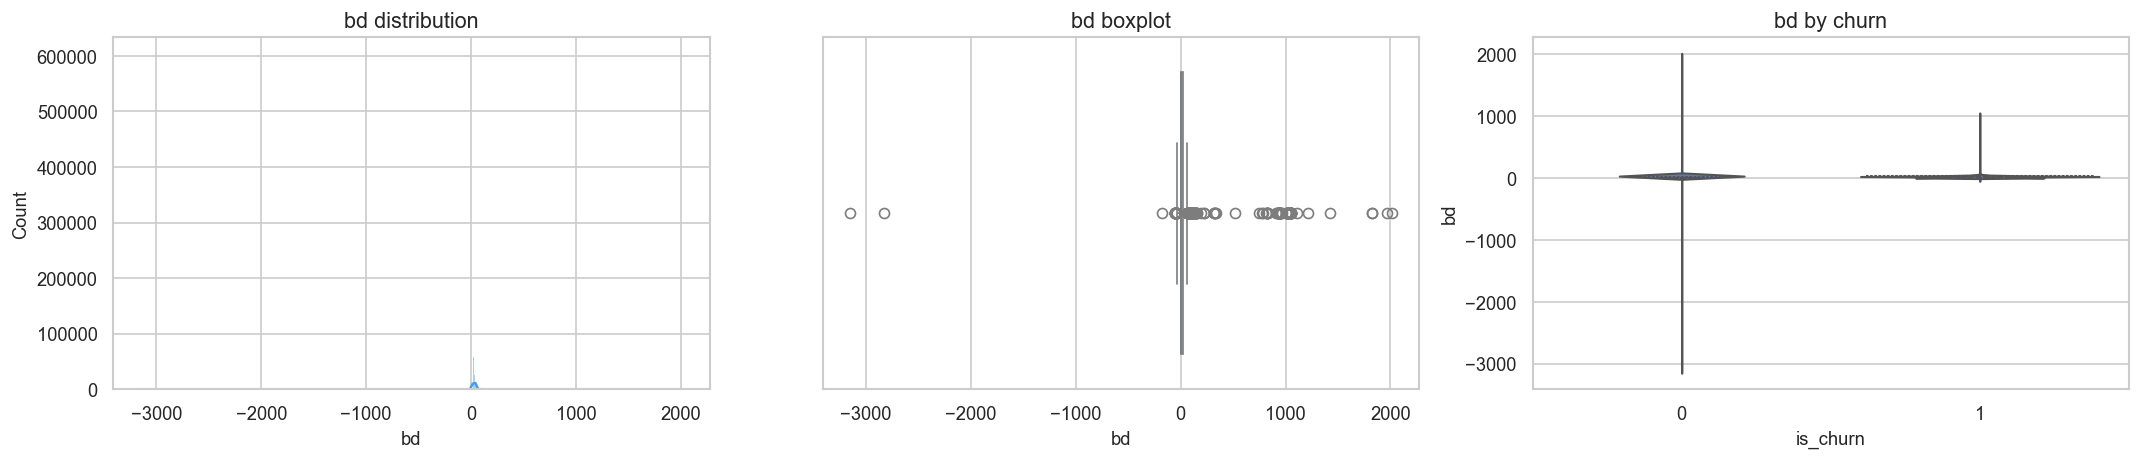

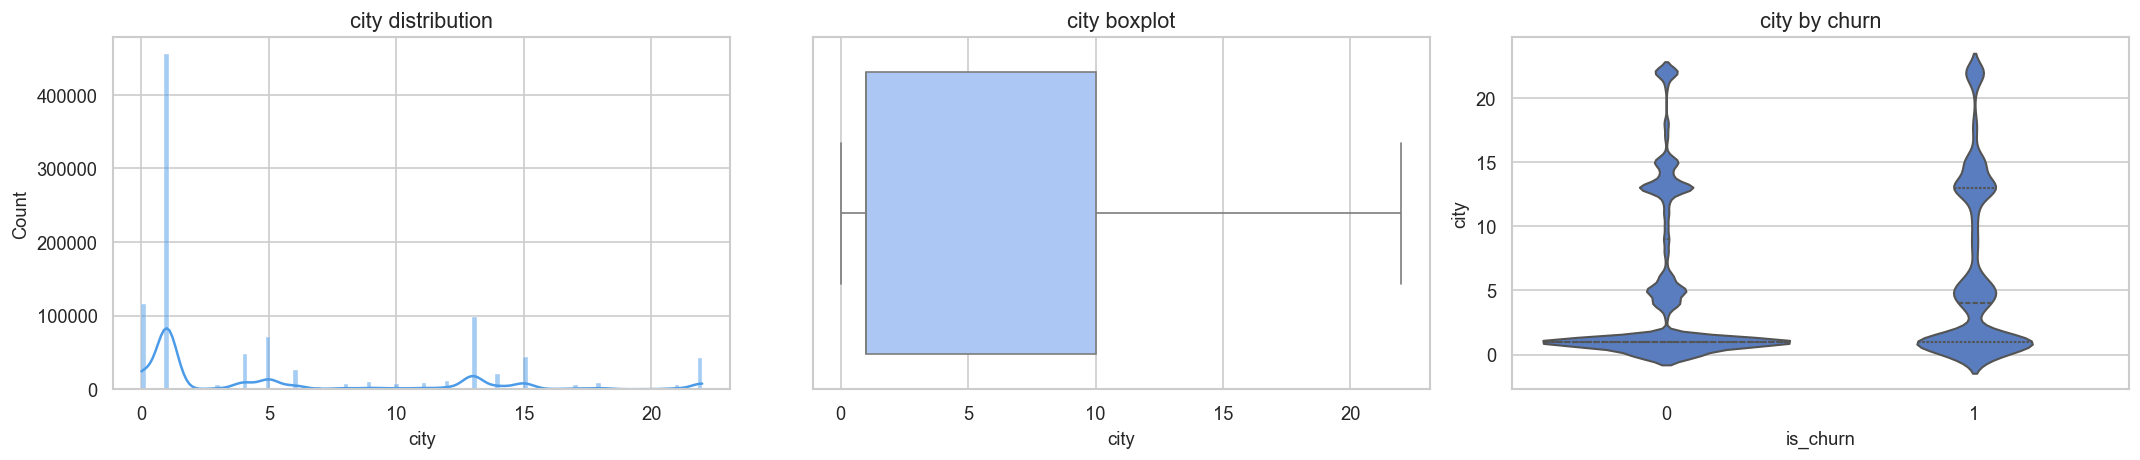

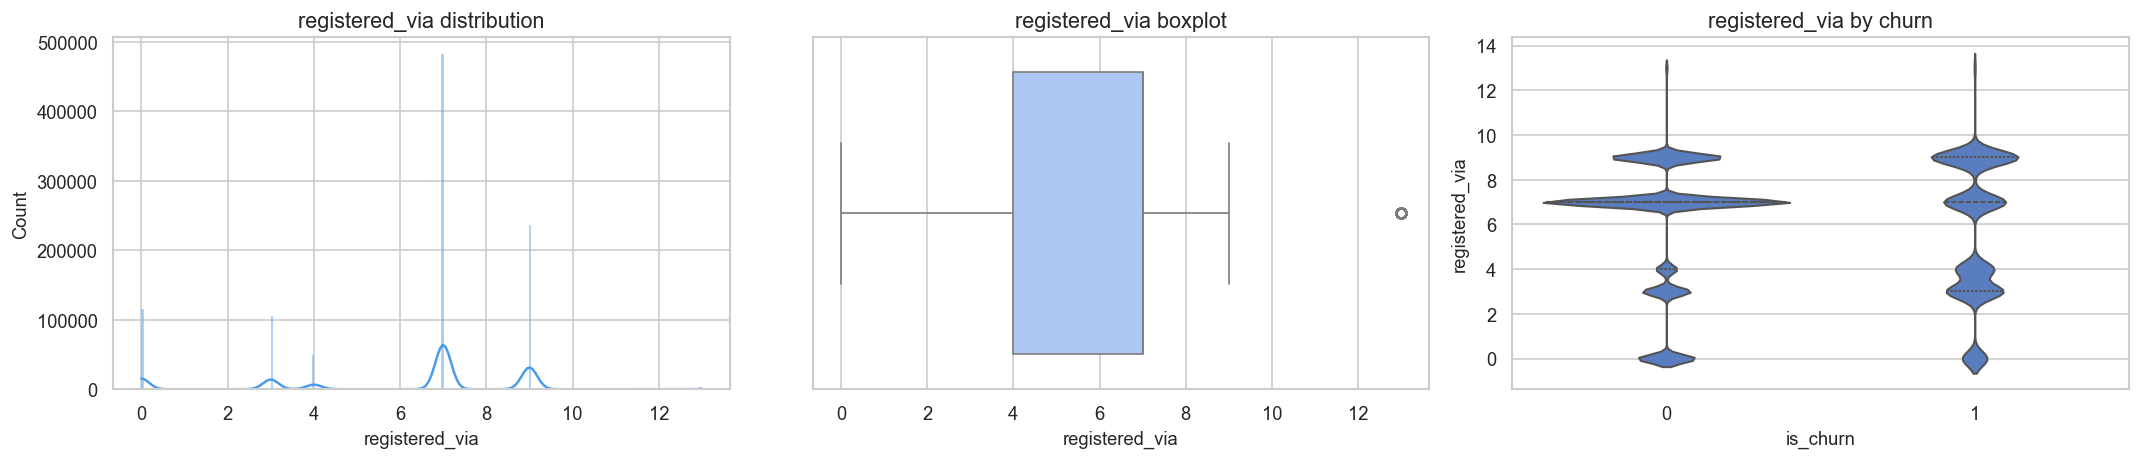

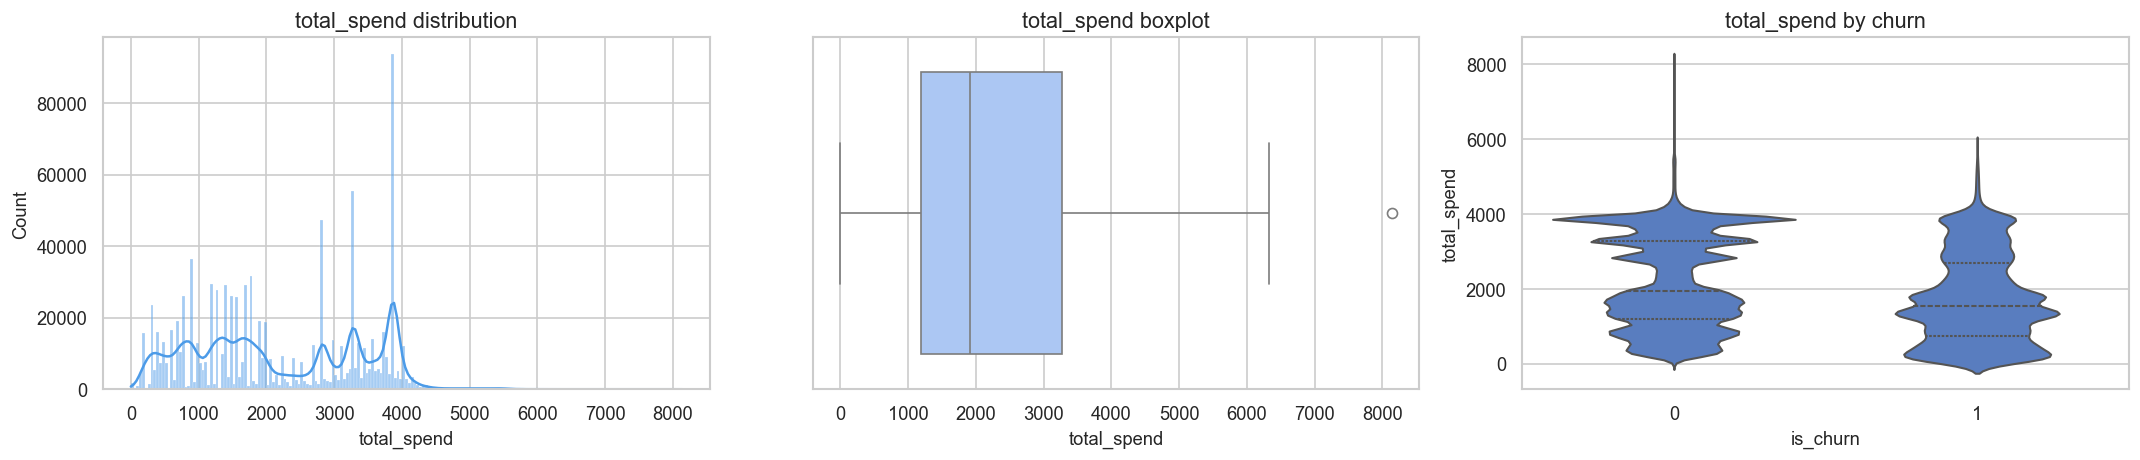

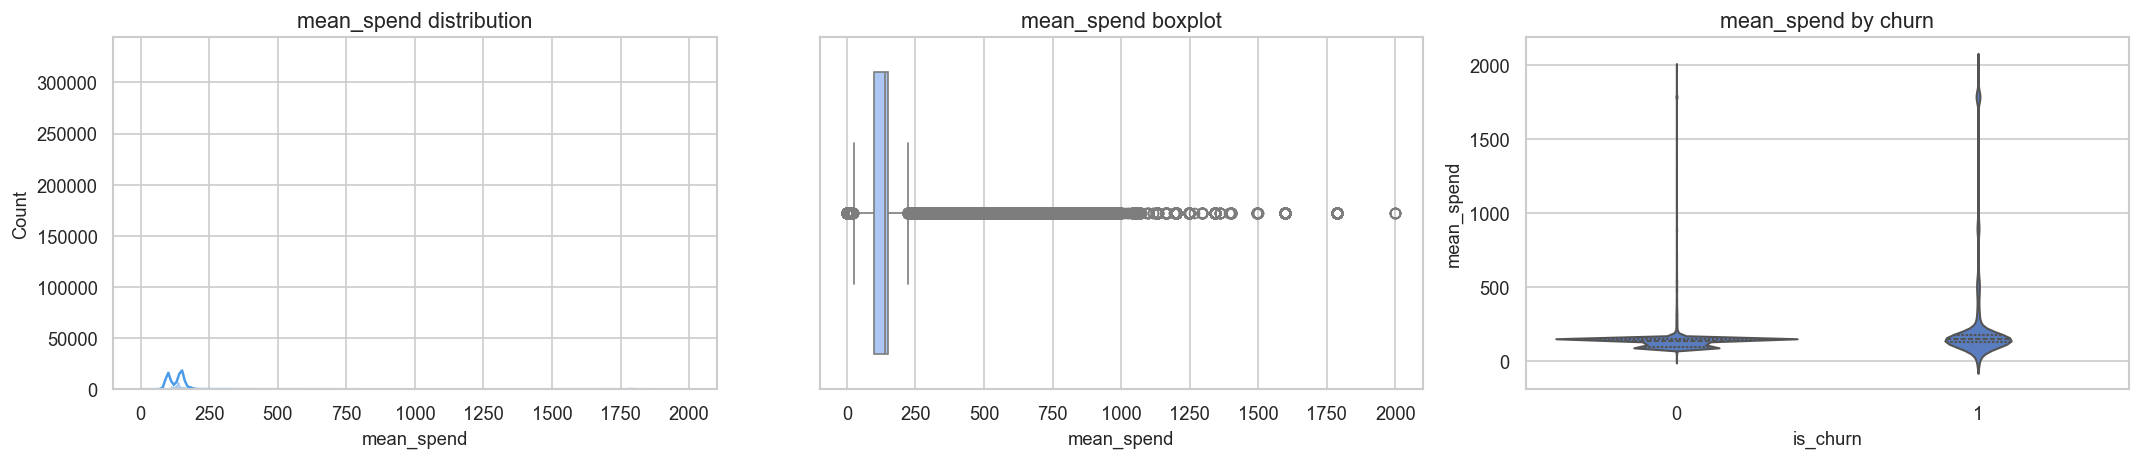

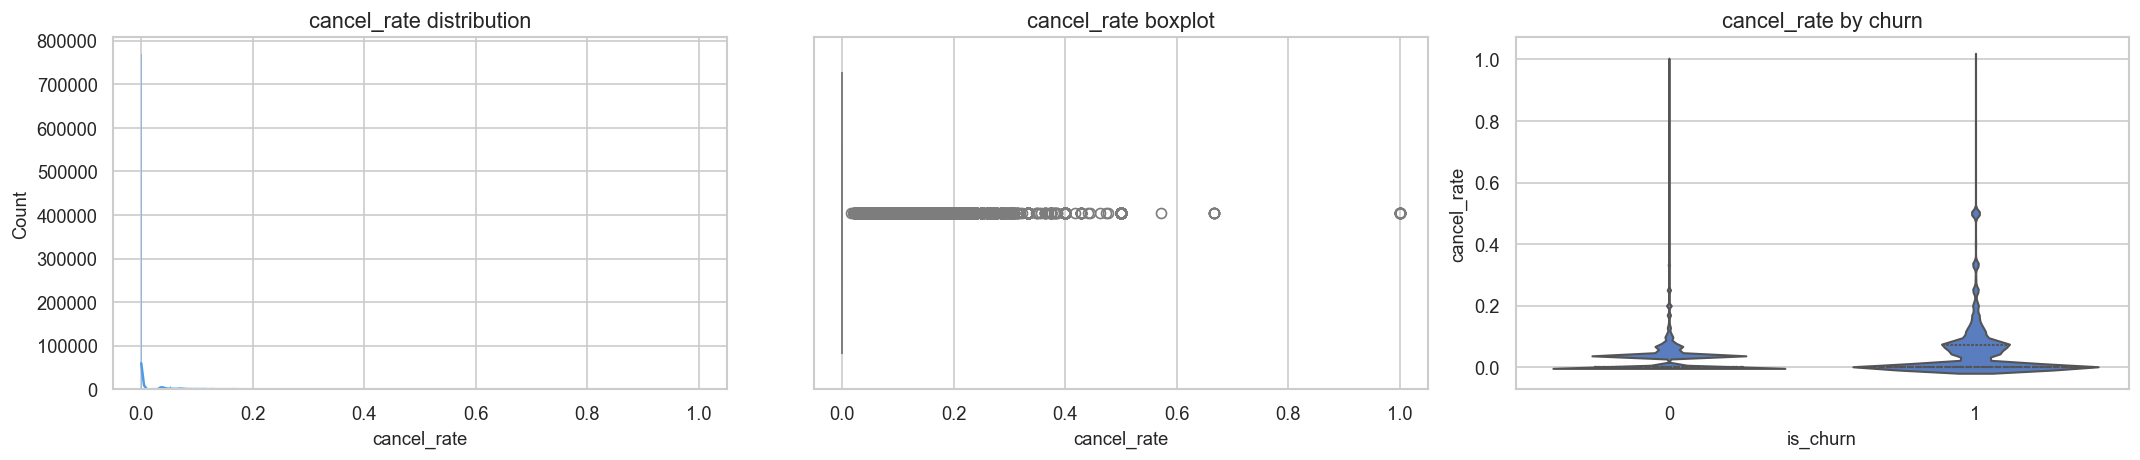

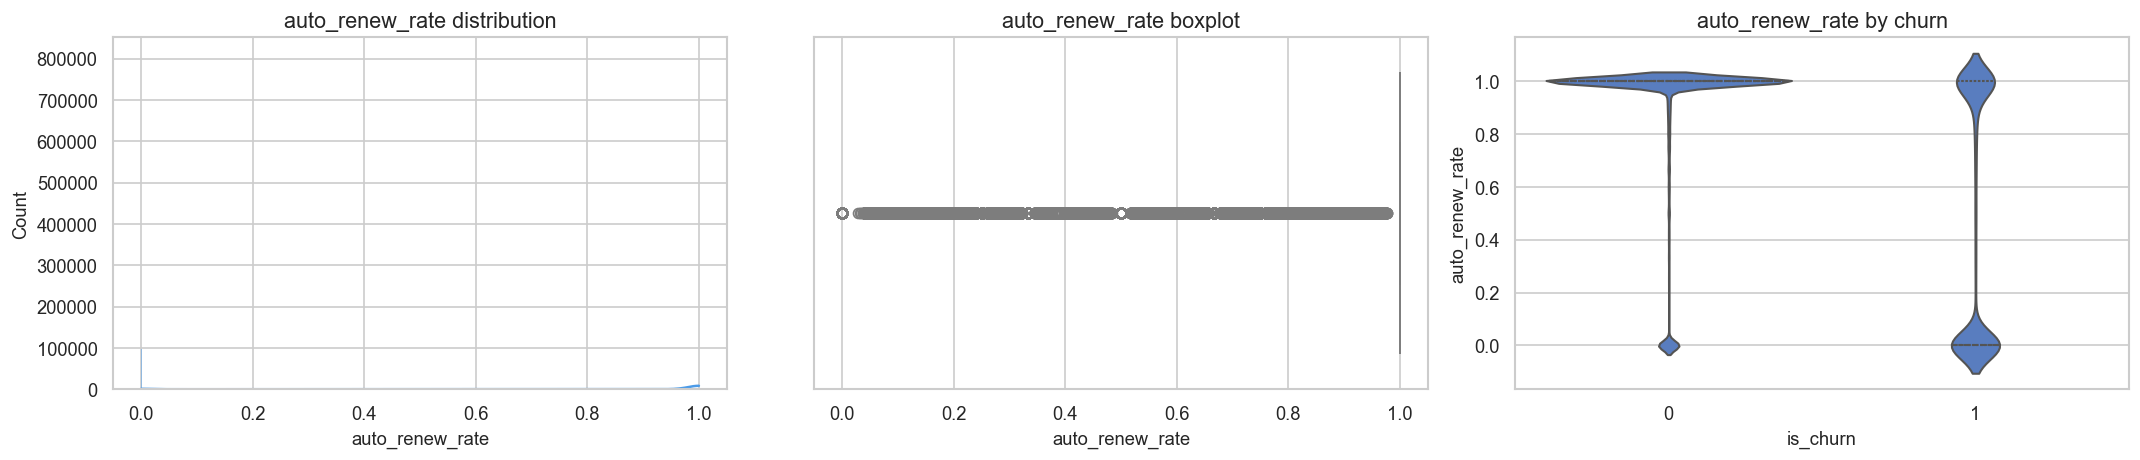

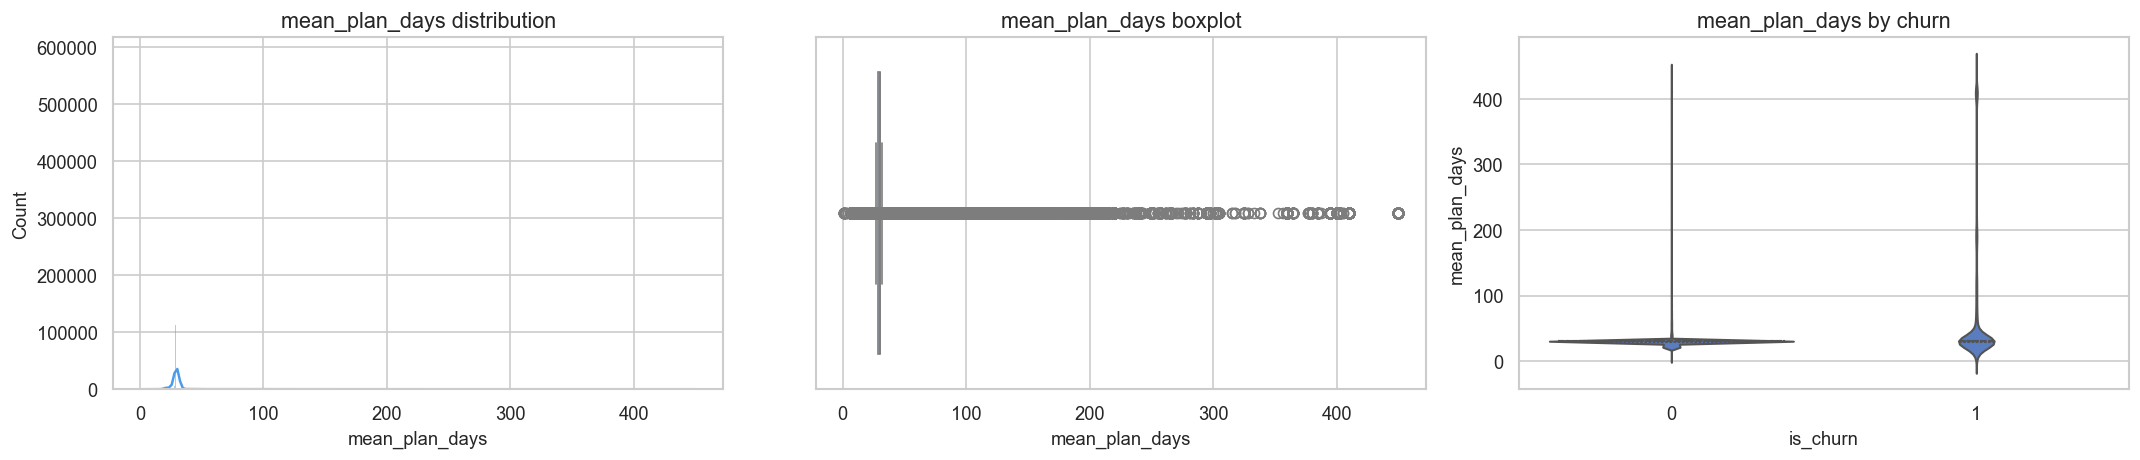

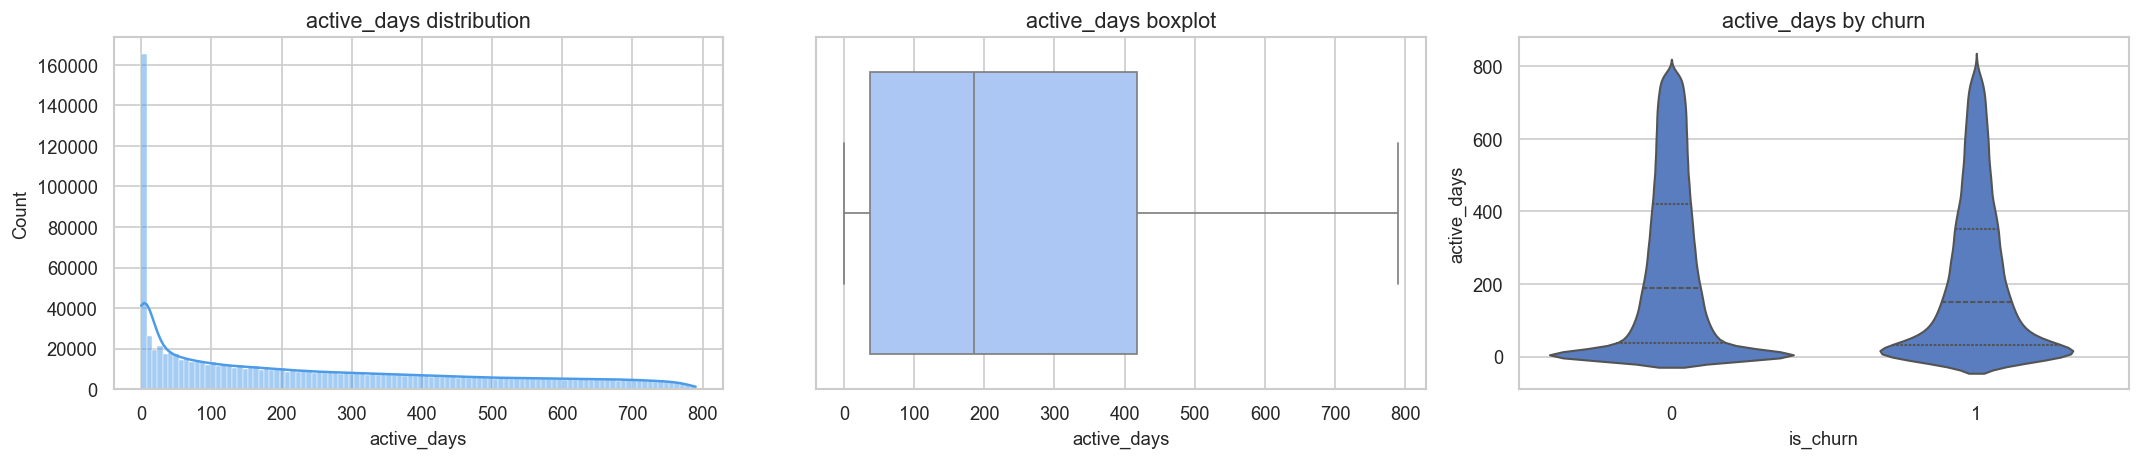

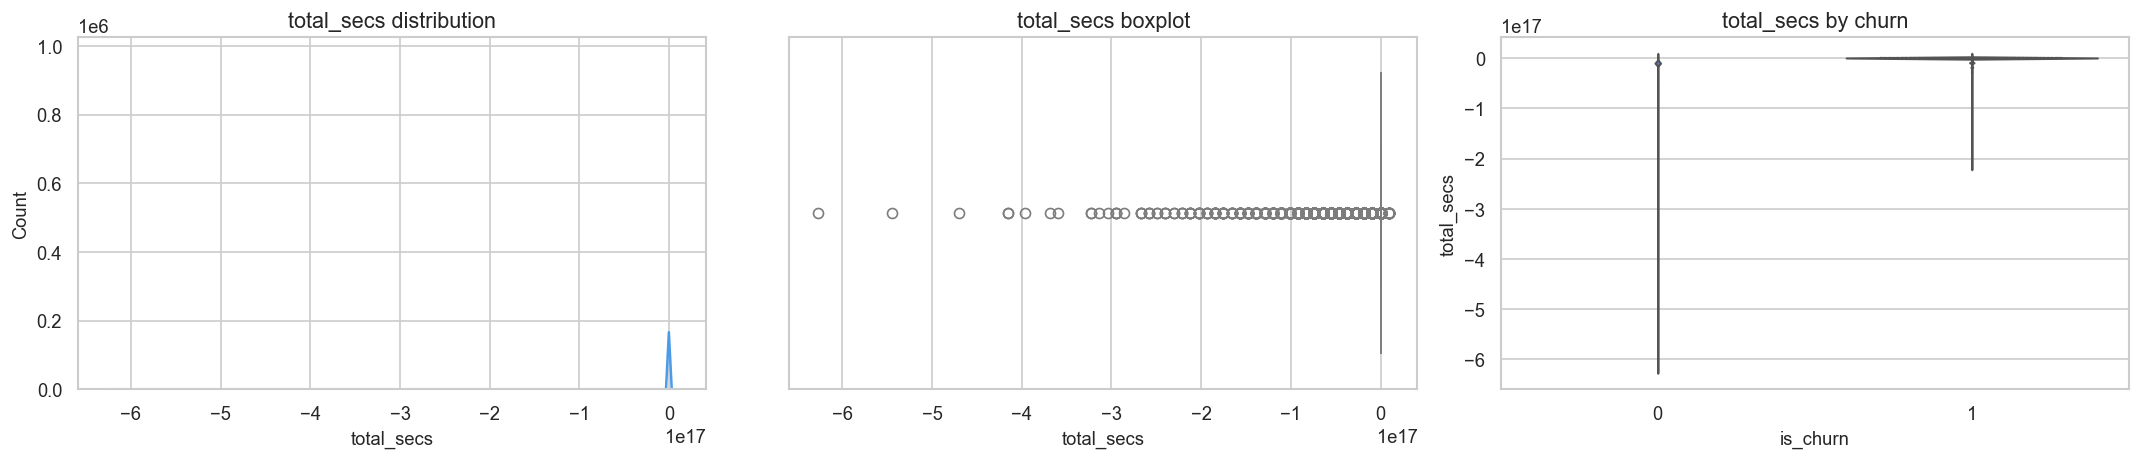

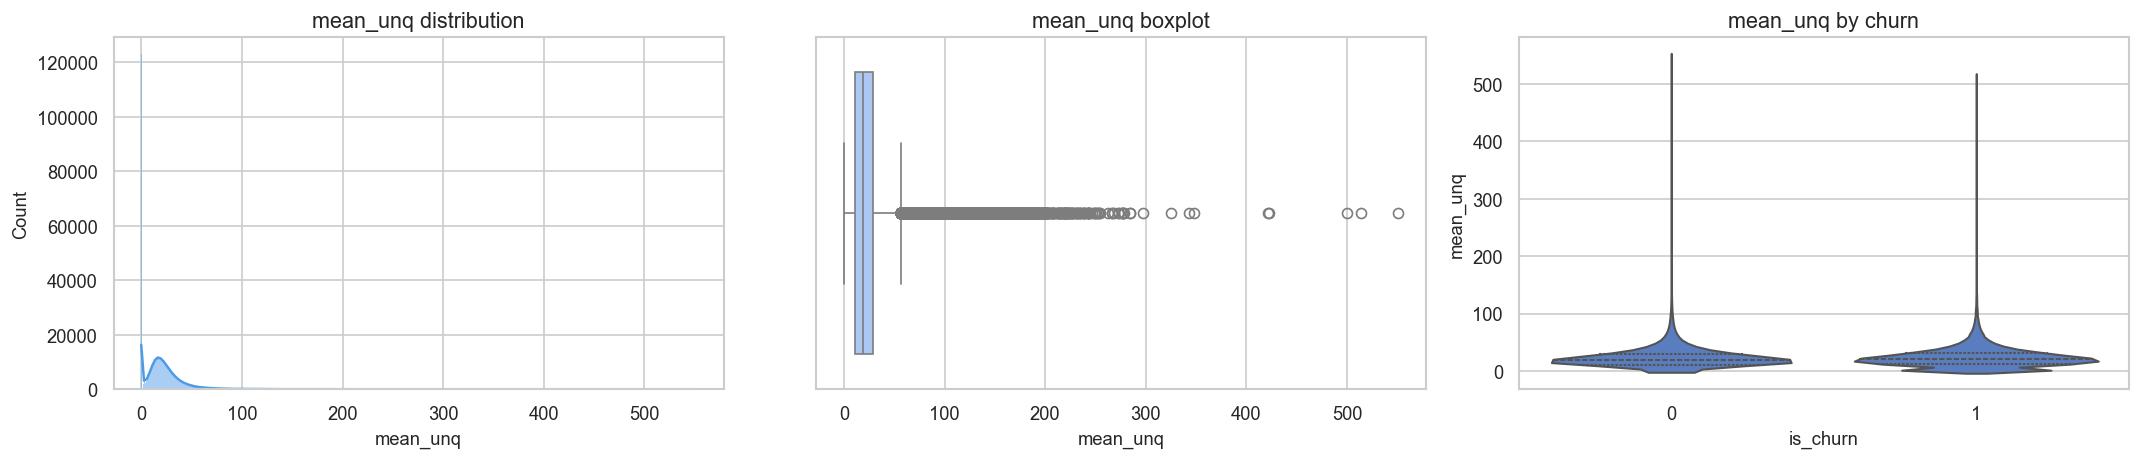

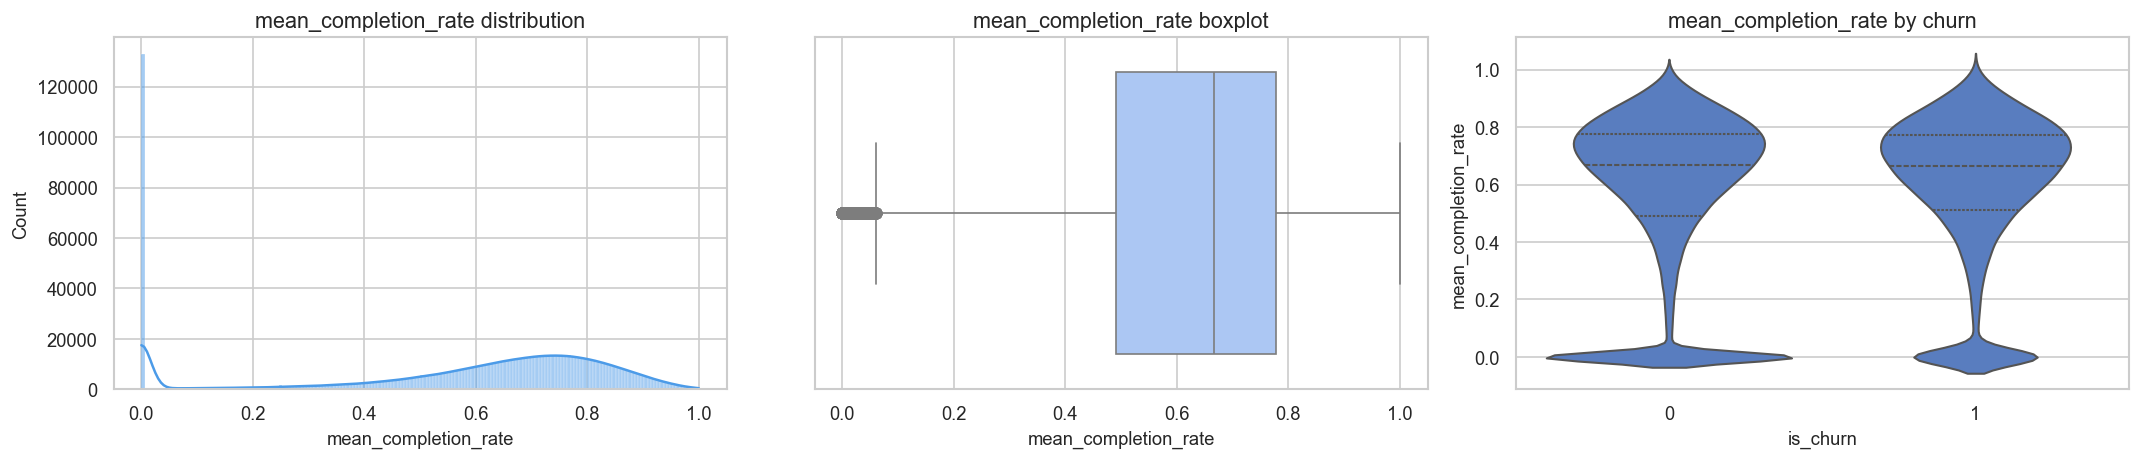

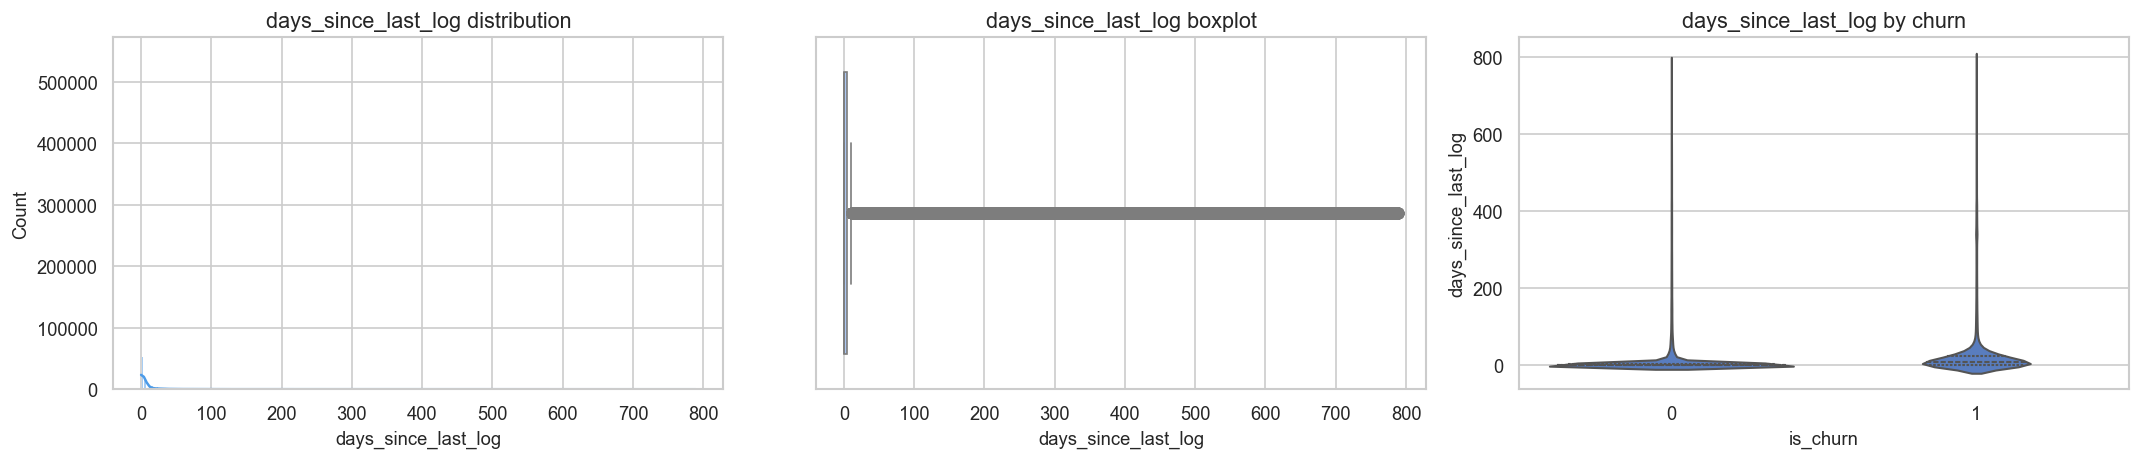

In [22]:
modeling_frame = build_modeling_frame(train, members, transactions, user_logs)
print(f'Modeling frame shape: {modeling_frame.shape[0]:,} rows x {modeling_frame.shape[1]} columns')

display(modeling_frame.head())

numeric_model_cols = modeling_frame.select_dtypes(include=[np.number]).columns.tolist()
plot_cols = [
    column for column in [
        'bd', 'city', 'registered_via', 'total_spend', 'mean_spend',
        'cancel_rate', 'auto_renew_rate', 'mean_plan_days', 'active_days',
        'total_secs', 'mean_unq', 'mean_completion_rate', 'days_since_last_log',
    ]
    if column in modeling_frame.columns
]

for column in plot_cols:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    sns.histplot(modeling_frame[column], kde=True, ax=axes[0], color='#4C9BE8')
    axes[0].set_title(f'{column} distribution')
    sns.boxplot(x=modeling_frame[column], ax=axes[1], color='#A0C4FF')
    axes[1].set_title(f'{column} boxplot')
    if 'is_churn' in modeling_frame.columns:
        sns.violinplot(data=modeling_frame, x='is_churn', y=column, ax=axes[2], inner='quartile')
        axes[2].set_title(f'{column} by churn')
    plt.tight_layout()
    plt.savefig(figures_dir / f'02_numeric_{column}.png', bbox_inches='tight')
    plt.show()

## 8 — Numerical variable analysis

Inspect the behavior of the numeric features in more detail. The focus here is on distribution shape, spread, outliers, and transformation opportunities.

Questions to answer:
- Which features are highly skewed?
- Which variables are dominated by a small number of extreme values?
- Are there obvious zero-inflated or long-tail patterns?
- Would log transforms, clipping, or binning make the variable more model-friendly?

The output of this section should guide both feature engineering and the choice of robust summaries in later modeling.

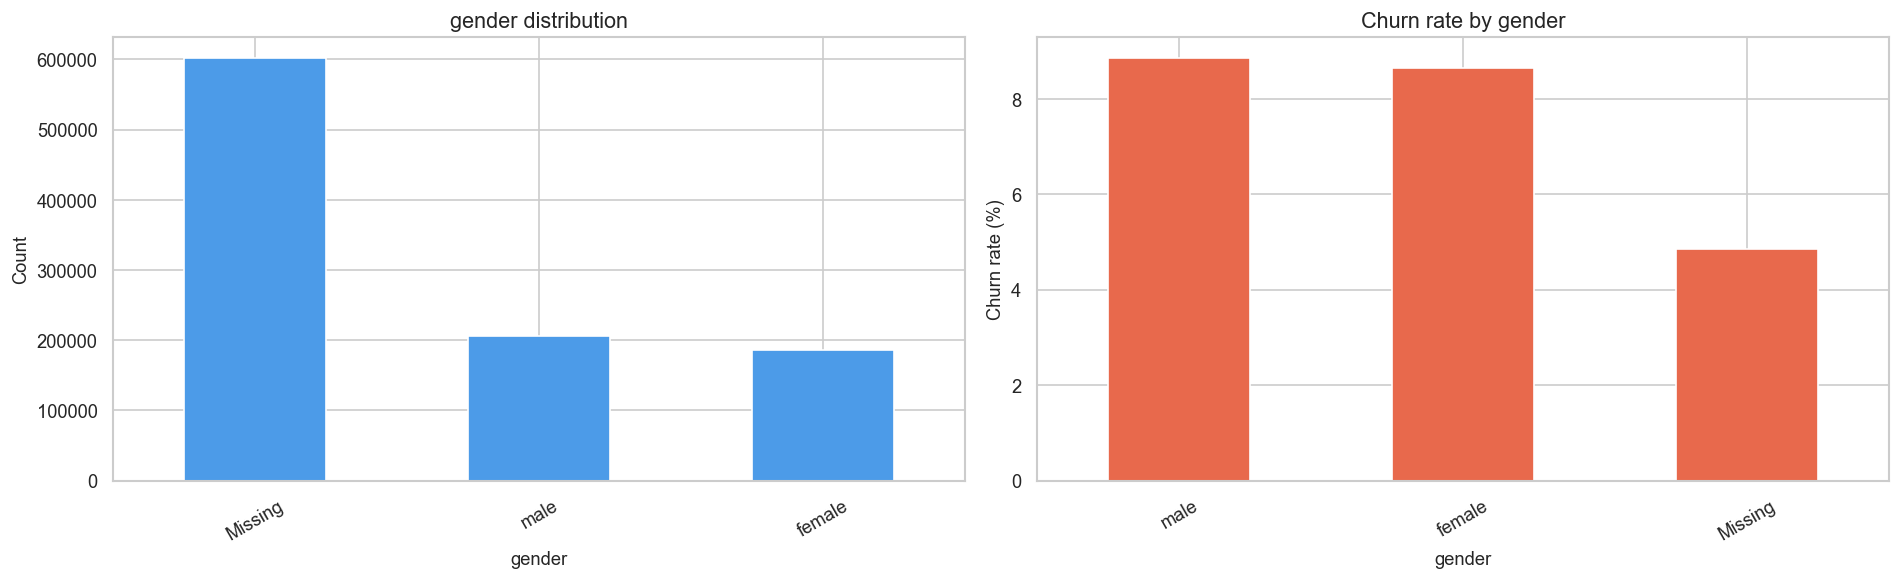

,count,churn_rate_pct
gender,,
Missing,601239,4.8588
female,185408,8.636628
male,206284,8.844603


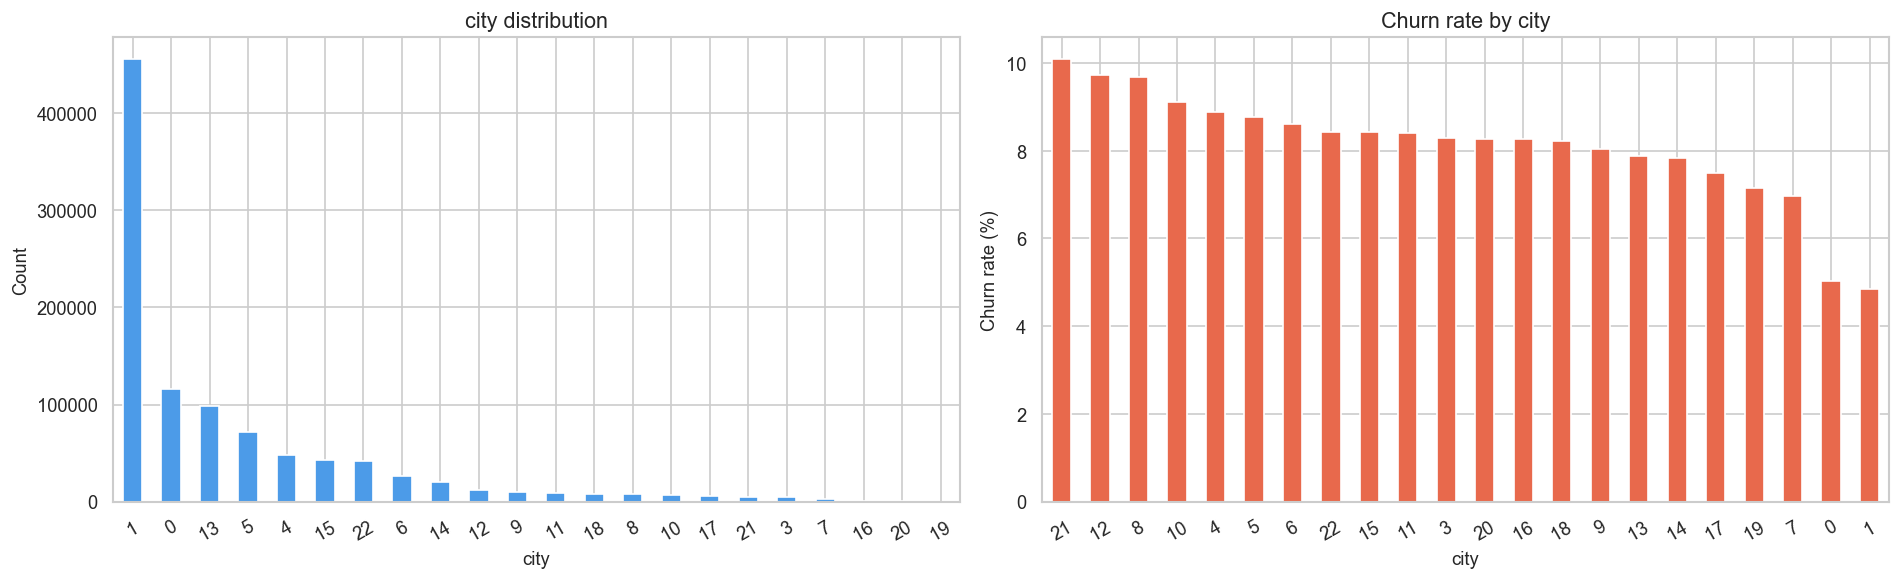

,count,churn_rate_pct
city,,
0,115770,5.023754
1,455389,4.841136
10,6533,9.107608
11,9036,8.410801
12,11554,9.719578
13,98281,7.873343
14,20167,7.844498
15,43356,8.423286
16,956,8.263598


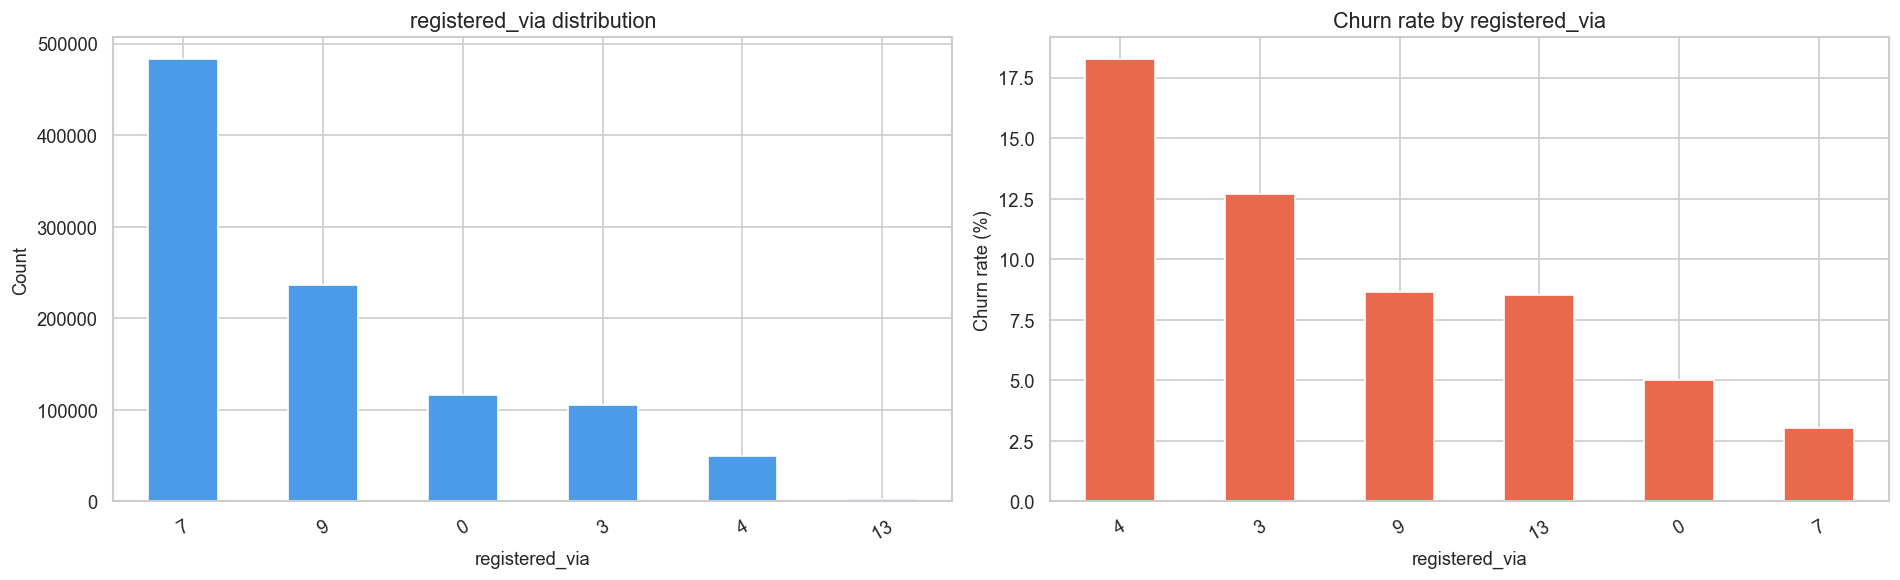

,count,churn_rate_pct
registered_via,,
0,115770,5.023754
13,3087,8.519598
3,105445,12.708995
4,49283,18.255788
7,482726,3.015997
9,236620,8.63621


In [23]:
categorical_candidates = [
    'gender',
    'city',
    'registered_via',
]
existing_categoricals = [column for column in categorical_candidates if column in modeling_frame.columns]

for column in existing_categoricals:
    counts = modeling_frame[column].astype('string').fillna('Missing').value_counts(dropna=False)
    churn_rate = modeling_frame.groupby(modeling_frame[column].astype('string').fillna('Missing'))['is_churn'].mean().sort_values(ascending=False) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    counts.plot(kind='bar', ax=axes[0], color='#4C9BE8', edgecolor='white')
    axes[0].set_title(f'{column} distribution')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=30)

    churn_rate.plot(kind='bar', ax=axes[1], color='#E8694C', edgecolor='white')
    axes[1].set_title(f'Churn rate by {column}')
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Churn rate (%)')
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig(figures_dir / f'03_categorical_{column}.png', bbox_inches='tight')
    plt.show()
    display(pd.DataFrame({'count': counts, 'churn_rate_pct': churn_rate}))

## 9 — Categorical variable analysis

Evaluate the categorical fields that may carry predictive signal. For churn problems, category balance and rare-category behavior can matter as much as raw numerical variation.

Focus on:
- Cardinality and dominant classes.
- Rare categories that may need grouping.
- Category-level churn rates and target separation.
- Potential leakage from categories that are created after the target event.

This section should help determine which categorical variables are worth encoding directly, which need consolidation, and which may not be useful in their raw form.

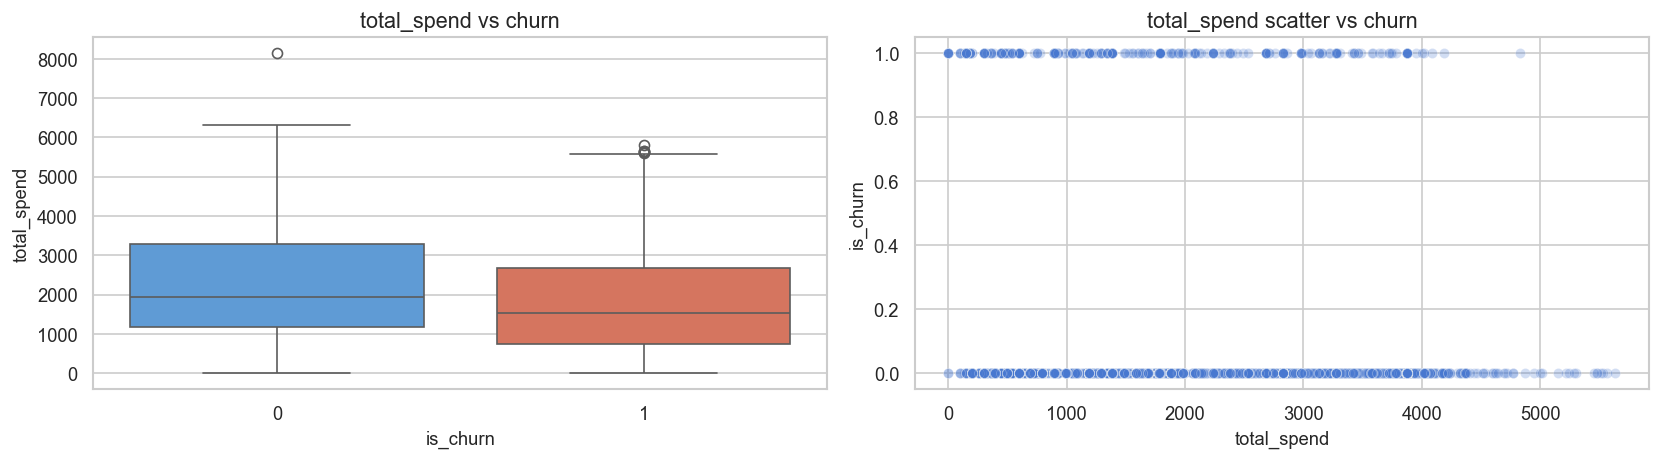

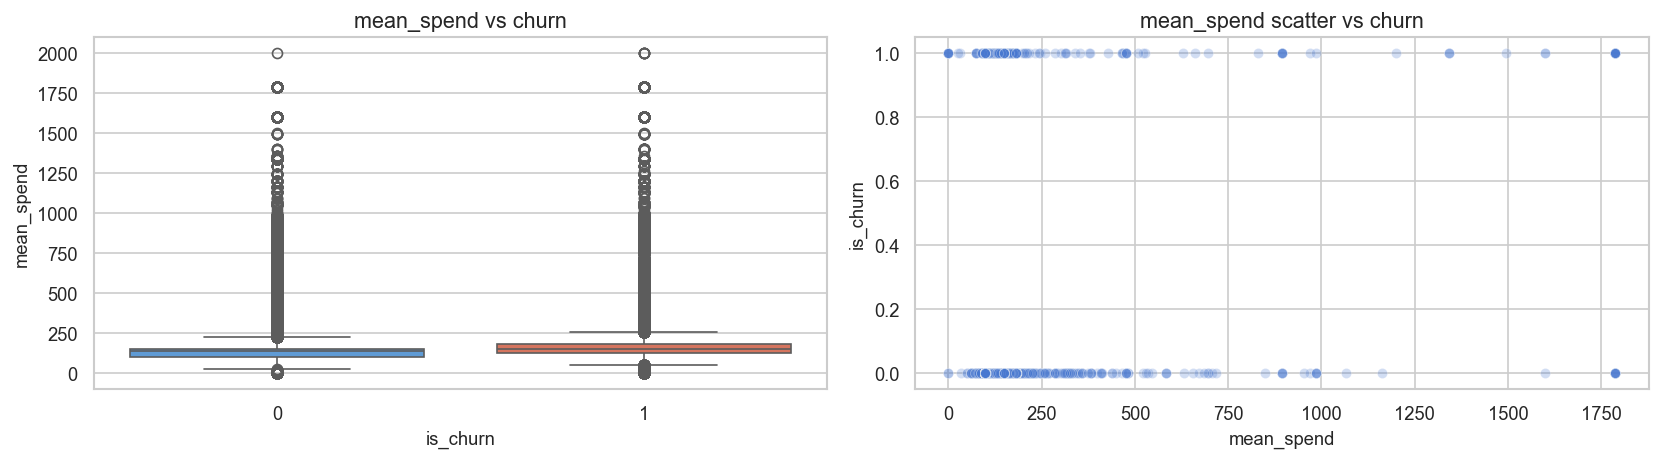

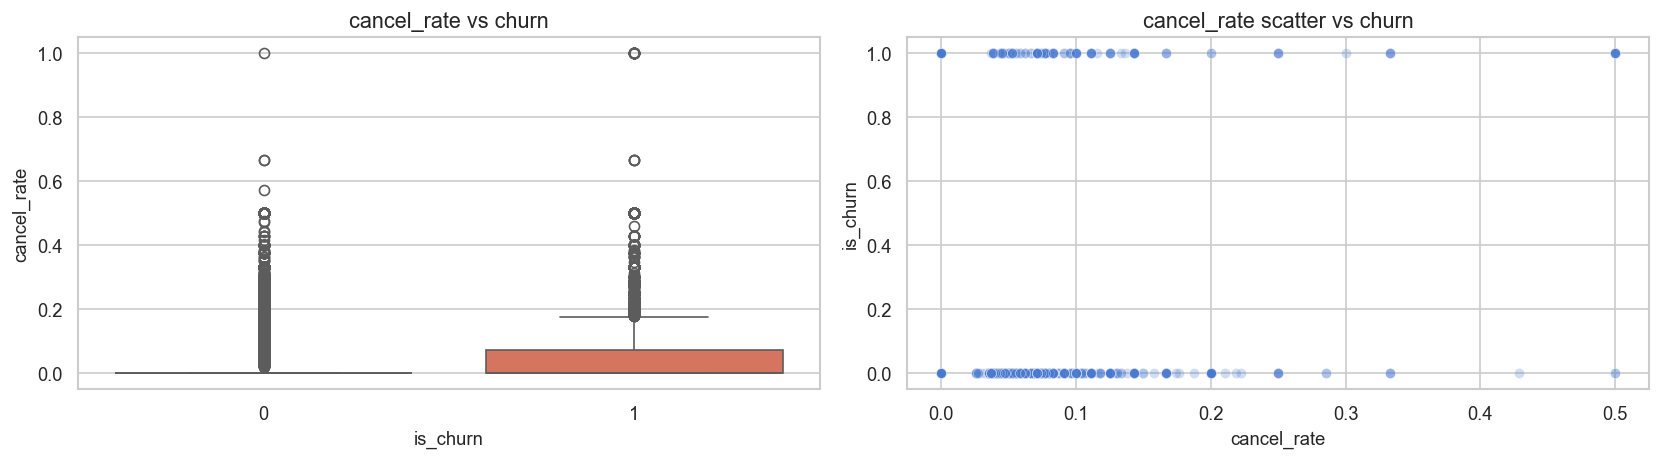

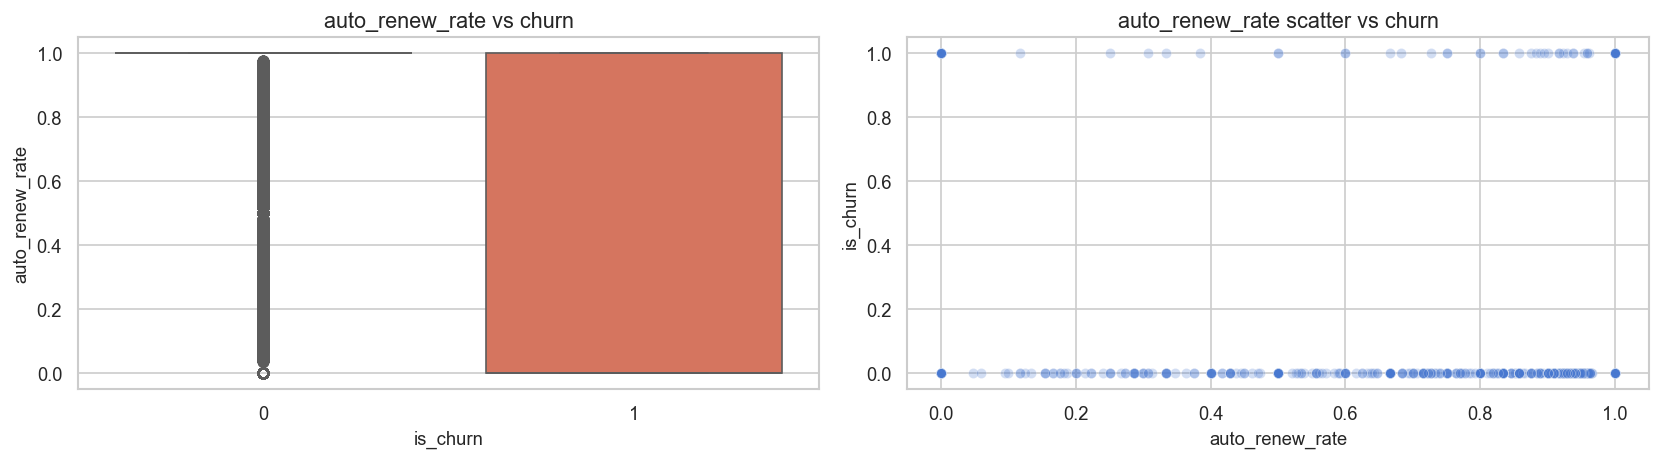

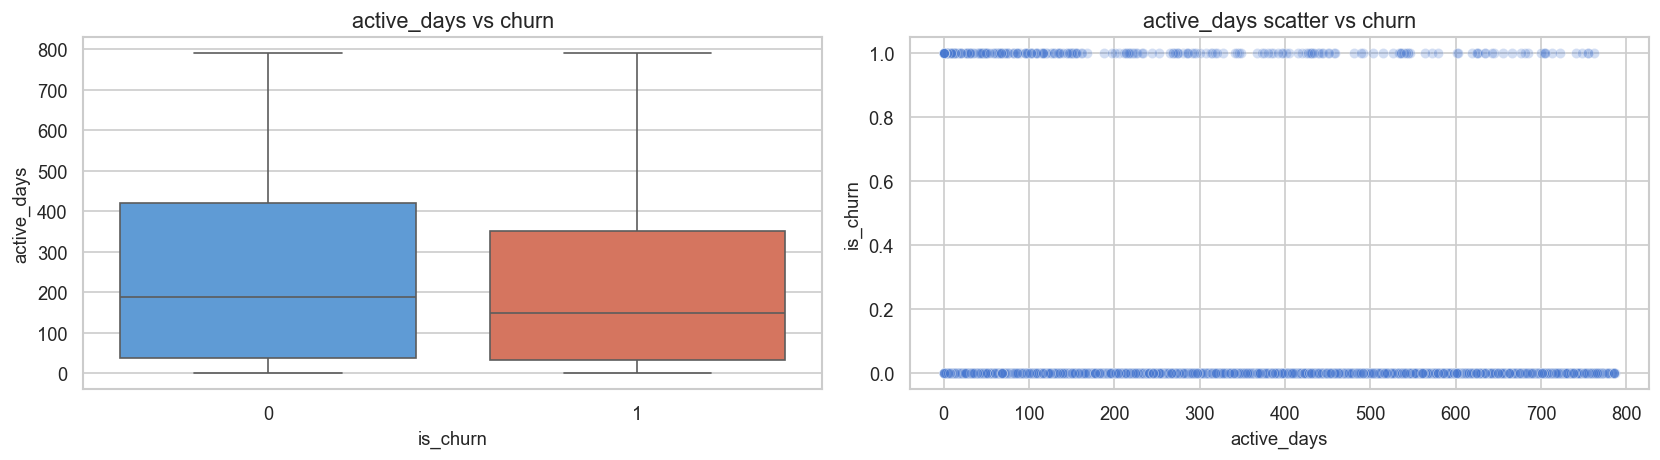

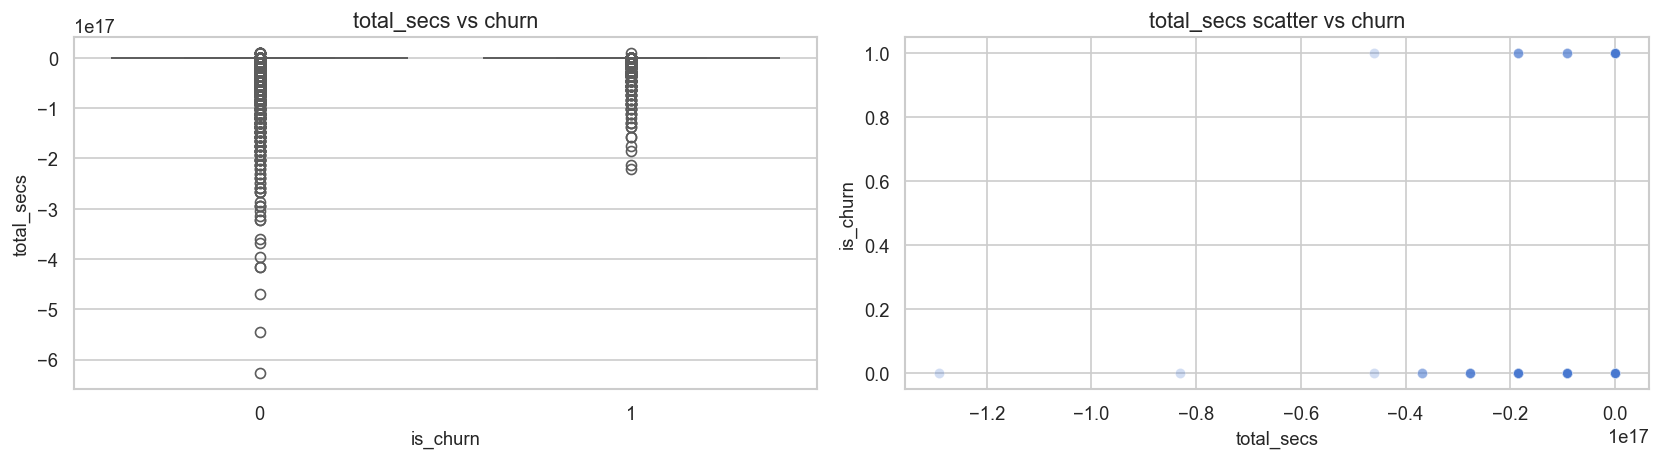

is_churn,0,1
total_spend,1950.000000,1530.000
mean_spend,138.565217,149.000
cancel_rate,0.000000,0.000
auto_renew_rate,1.000000,0.000
active_days,188.000000,149.000
total_secs,855675.383000,712593.049


In [24]:
relationship_pairs = [
    ('total_spend', 'is_churn'),
    ('mean_spend', 'is_churn'),
    ('cancel_rate', 'is_churn'),
    ('auto_renew_rate', 'is_churn'),
    ('active_days', 'is_churn'),
    ('total_secs', 'is_churn'),
]

for feature, target in relationship_pairs:
    if feature not in modeling_frame.columns:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.boxplot(data=modeling_frame, x=target, y=feature, ax=axes[0], palette=['#4C9BE8', '#E8694C'])
    axes[0].set_title(f'{feature} vs churn')
    sns.scatterplot(data=modeling_frame.sample(min(len(modeling_frame), 5000), random_state=config['project']['random_state']), x=feature, y='is_churn', alpha=0.25, ax=axes[1])
    axes[1].set_title(f'{feature} scatter vs churn')
    plt.tight_layout()
    plt.savefig(figures_dir / f'04_relationship_{feature}.png', bbox_inches='tight')
    plt.show()

summary_by_churn = modeling_frame.groupby('is_churn')[['total_spend', 'mean_spend', 'cancel_rate', 'auto_renew_rate', 'active_days', 'total_secs']].median(numeric_only=True)
display(summary_by_churn.T)

## 10 — Relationships and correlations

Study how the main features relate to each other and to the churn target. This section helps surface redundant variables, strong associations, and possible interactions worth testing later.

Suggested checks:
- Correlation among numeric features.
- Feature-to-target relationships.
- Simple group comparisons by churn label.
- Potential multicollinearity or duplicate signals.

The goal is not to exhaustively model interactions here, but to identify the relationships that are most worth preserving or engineering in the modeling stage.

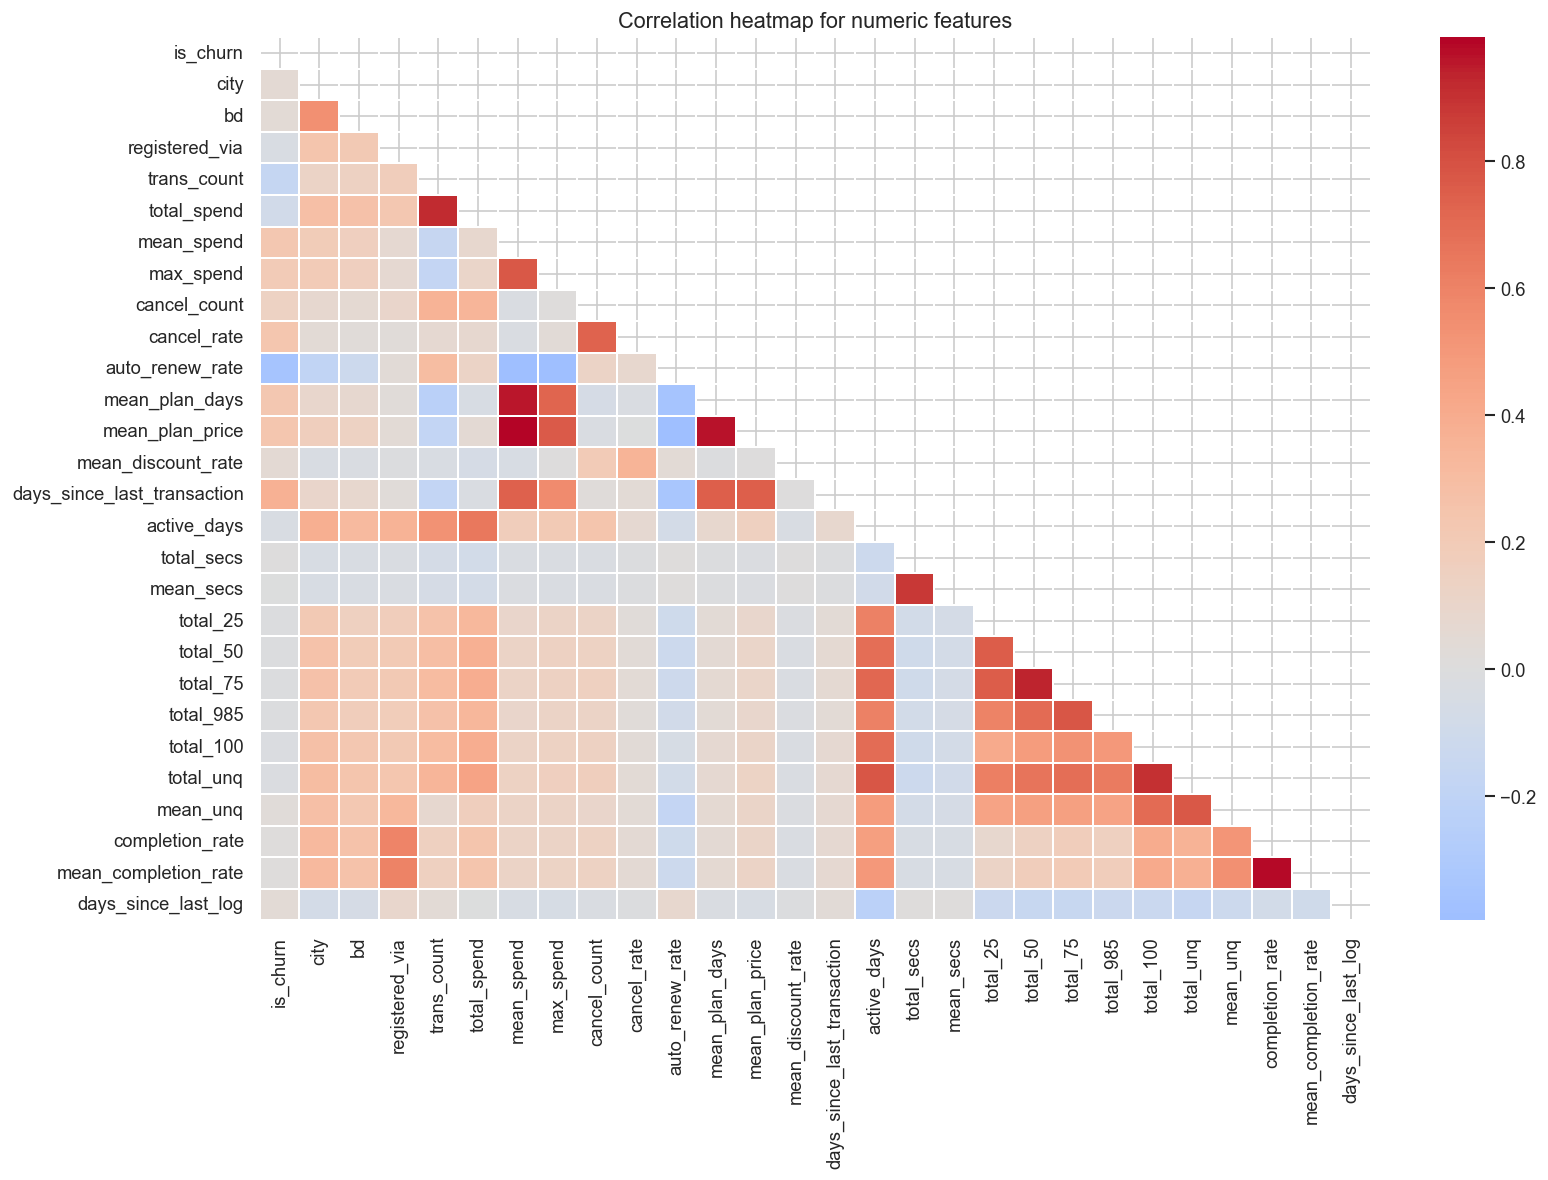

,correlation_with_churn
days_since_last_transaction,0.369773
auto_renew_rate,-0.349656
mean_plan_price,0.239263
cancel_rate,0.236278
mean_spend,0.233813
mean_plan_days,0.233014
max_spend,0.201361
trans_count,-0.164563
cancel_count,0.138588
total_spend,-0.090292


In [25]:
numeric_frame = modeling_frame.select_dtypes(include=[np.number]).copy()
corr_matrix = numeric_frame.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, linewidths=0.2)
plt.title('Correlation heatmap for numeric features')
plt.tight_layout()
plt.savefig(figures_dir / '05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

target_corr = corr_matrix['is_churn'].drop('is_churn').sort_values(key=lambda s: s.abs(), ascending=False)
display(target_corr.head(15).to_frame('correlation_with_churn'))

## 11 — Outlier detection

Identify unusually large or unusual values that may reflect either real extreme behavior or data quality issues. In churn analysis, outliers can be informative, but they can also distort summaries and model training if left unhandled.

Questions to answer:
- Which variables have the strongest outlier concentration?
- Are the extreme values plausible for the business context?
- Should values be capped, transformed, or kept as-is?

The outcome should be a small set of handling rules that can be reused during feature engineering.

,column,outlier_count,outlier_pct,lower_bound,upper_bound
2,cancel_rate,223745,22.533791,0.000000e+00,0.000000e+00
3,auto_renew_rate,181756,18.304998,1.000000e+00,1.000000e+00
7,mean_completion_rate,135815,13.678191,6.027343e-02,1.207071e+00
5,total_secs,83872,8.446911,-3.559217e+06,6.192255e+06
6,mean_unq,42461,4.276329,-1.635824e+01,5.659707e+01
1,mean_spend,35909,3.616465,2.400000e+01,2.240000e+02
0,total_spend,1,0.000101,-1.947000e+03,6.413000e+03
4,active_days,0,0.000000,-5.330000e+02,9.870000e+02


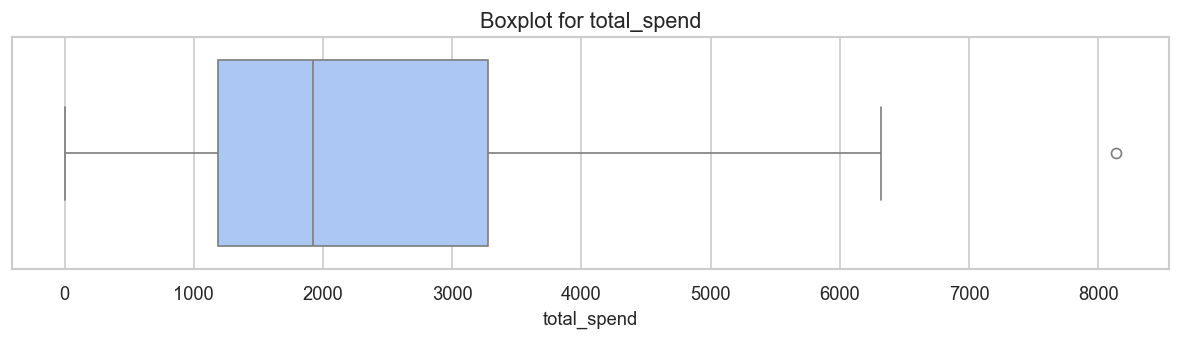

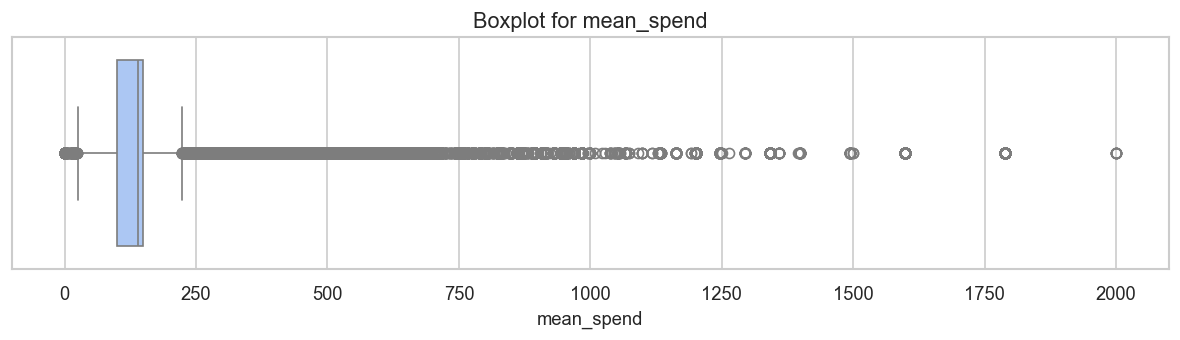

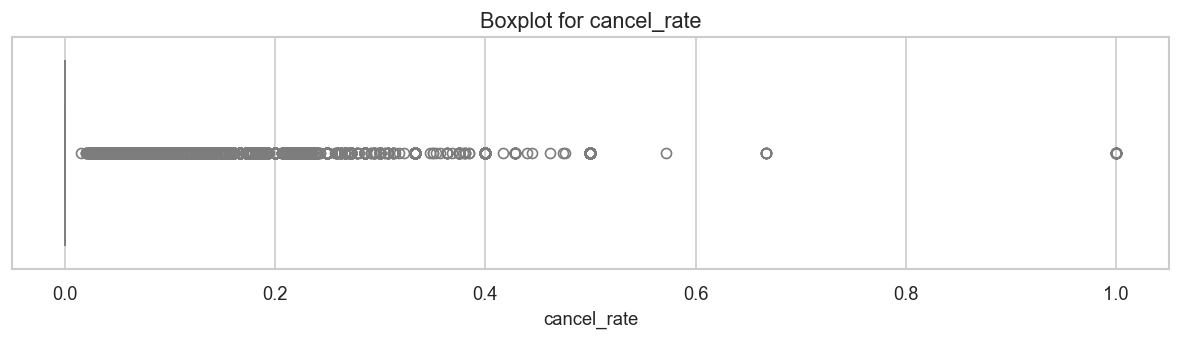

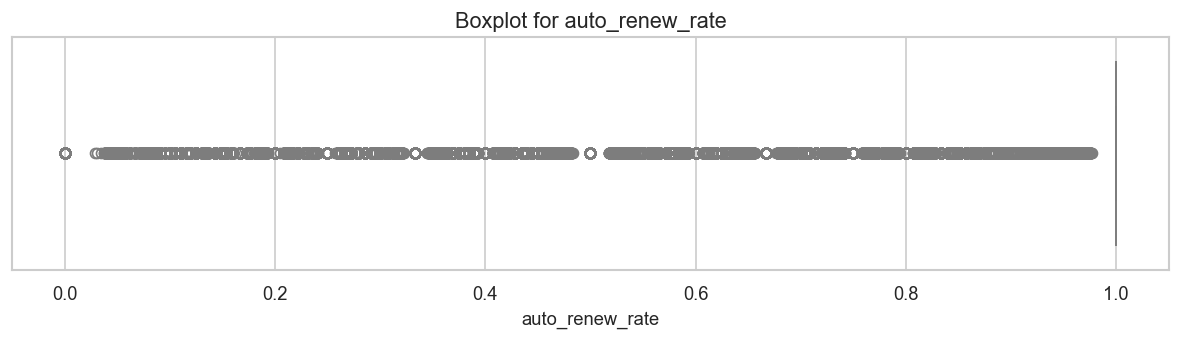

In [26]:
def iqr_outliers(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Count IQR outliers for selected numeric columns."""
    rows = []
    for column in columns:
        series = frame[column].dropna()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_count = int(((series < lower) | (series > upper)).sum())
        rows.append({
            'column': column,
            'outlier_count': outlier_count,
            'outlier_pct': outlier_count / len(series) * 100,
            'lower_bound': lower,
            'upper_bound': upper,
        })
    return pd.DataFrame(rows).sort_values('outlier_pct', ascending=False)

outlier_columns = [column for column in ['total_spend', 'mean_spend', 'cancel_rate', 'auto_renew_rate', 'active_days', 'total_secs', 'mean_unq', 'mean_completion_rate'] if column in modeling_frame.columns]
outlier_summary = iqr_outliers(modeling_frame, outlier_columns)
display(outlier_summary)

for column in outlier_columns[:4]:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=modeling_frame[column], color='#A0C4FF')
    plt.title(f'Boxplot for {column}')
    plt.tight_layout()
    plt.savefig(figures_dir / f'06_outlier_box_{column}.png', bbox_inches='tight')
    plt.show()

## 12 — Modeling preview

Take a quick look at the final modeling frame before feature engineering begins. This is where we validate that the merged dataset is suitable for training and that the basic target behavior matches expectations.

Preview items:
- Final row and column counts.
- Target distribution and class imbalance.
- Columns that are clearly candidate features versus columns that may be dropped.
- Obvious leakage risks or fields that should remain out of model input.

This section is intentionally lightweight: it should connect EDA findings to the modeling plan without duplicating the full training pipeline.

In [27]:
merge_preview_cols = [
    column for column in [
        'msno', 'is_churn', 'bd', 'gender', 'registered_via', 'total_spend',
        'cancel_rate', 'auto_renew_rate', 'active_days', 'total_secs',
        'mean_completion_rate', 'days_since_last_log',
    ]
    if column in modeling_frame.columns
]

print(f'Modeling frame shape: {modeling_frame.shape[0]:,} rows x {modeling_frame.shape[1]} columns')
display(modeling_frame[merge_preview_cols].head())

overview = pd.DataFrame({
    'column': modeling_frame.columns,
    'dtype': modeling_frame.dtypes.astype(str).values,
    'null_count': modeling_frame.isna().sum().values,
})
overview['null_pct'] = overview['null_count'] / len(modeling_frame) * 100
display(overview.sort_values(['null_pct', 'column'], ascending=[False, True]).head(25))

Modeling frame shape: 992,931 rows x 34 columns


,msno,is_churn,bd,gender,registered_via,total_spend,cancel_rate,auto_renew_rate,active_days,total_secs,mean_completion_rate,days_since_last_log
0,waLDQMmcOu2jLDaV1ddDkgCrB/jl6sD66Xzs0Vqax1Y=,1,36,female,9,149.0,0.000000,0.000000,26.0,1.080519e+05,0.769370,20.0
1,QA7uiXy8vIbUSPOkCf9RwQ3FsT8jVq2OxDr8zqa7bRQ=,1,38,male,9,3458.0,0.086957,0.956522,521.0,2.615312e+06,0.881958,13.0
2,fGwBva6hikQmTJzrbz/2Ezjm5Cth5jZUNvXigKK2AFA=,1,27,female,9,1492.0,0.100000,0.800000,237.0,2.597385e+06,0.743281,28.0
3,mT5V8rEpa+8wuqi6x0DoVd3H5icMKkE9Prt49UlmK+4=,1,23,female,9,1788.0,0.000000,0.000000,735.0,4.945309e+06,0.570658,7.0
4,XaPhtGLk/5UvvOYHcONTwsnH97P4eGECeq+BARGItRw=,1,27,male,9,3576.0,0.000000,0.000000,758.0,1.864415e+07,0.900793,0.0


,column,dtype,null_count,null_pct
4,gender,string,601239,60.551942
32,last_log_date,datetime64[ns],123005,12.388071
6,registration_init_time,datetime64[ns],115770,11.659420
20,active_days,float64,0,0.000000
13,auto_renew_rate,float64,0,0.000000
3,bd,Int64,0,0.000000
11,cancel_count,float64,0,0.000000
12,cancel_rate,float64,0,0.000000
2,city,Int64,0,0.000000
30,completion_rate,float64,0,0.000000


## 13 — Summary and next steps

Summarize the most important findings from the notebook in a form that can directly guide the next pipeline stage.

The summary should answer:
- What is the overall quality of the data?
- Which issues need preprocessing or feature engineering?
- Which variables appear promising for modeling?
- What should be validated next before training models?

End with clear next steps, such as feature engineering priorities, encoding strategy, and any data-quality follow-up that should happen before model training.

In [28]:
summary_rows = [
    {
        'topic': 'Target imbalance',
        'finding': f"Churn rate = {train['is_churn'].mean() * 100:.2f}%",
        'next_step': 'Use AUC-PR, class weights, and threshold tuning.',
    },
    {
        'topic': 'Missing data',
        'finding': 'Merged tables contain missing values, especially from optional histories.',
        'next_step': 'Treat no-activity as signal and create explicit missing indicators.',
    },
    {
        'topic': 'Candidate signals',
        'finding': 'Transaction and listening aggregates show the strongest churn separation.',
        'next_step': 'Prioritize recency, frequency, spend, cancel_rate, and auto_renew features.',
    },
    {
        'topic': 'Outliers',
        'finding': 'Spending and listening metrics are heavy-tailed.',
        'next_step': 'Consider robust scaling, log transforms, or clipping.',
    },
    {
        'topic': 'Category effects',
        'finding': 'Gender, city, and registration channel can still carry useful churn signal.',
        'next_step': 'Encode categories carefully and inspect churn rate per group.',
    },
]

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print('\nRecommended feature engineering priorities:')
for item in [
    'Recency features: days since last transaction and last log',
    'Volume features: active days, transaction count, total listening seconds',
    'Value features: total spend, mean spend, discount rate',
    'Behavior features: cancel_rate, auto_renew_rate, completion_rate',
    'Demographic features: age bucket, city, gender, registration channel',
]:
    print(f'- {item}')

,topic,finding,next_step
0,Target imbalance,Churn rate = 6.39%,"Use AUC-PR, class weights, and threshold tuning."
1,Missing data,"Merged tables contain missing values, especial...",Treat no-activity as signal and create explici...
2,Candidate signals,Transaction and listening aggregates show the ...,"Prioritize recency, frequency, spend, cancel_r..."
3,Outliers,Spending and listening metrics are heavy-tailed.,"Consider robust scaling, log transforms, or cl..."
4,Category effects,"Gender, city, and registration channel can sti...",Encode categories carefully and inspect churn ...



Recommended feature engineering priorities:
- Recency features: days since last transaction and last log
- Volume features: active days, transaction count, total listening seconds
- Value features: total spend, mean spend, discount rate
- Behavior features: cancel_rate, auto_renew_rate, completion_rate
- Demographic features: age bucket, city, gender, registration channel
